In [ ]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
from specutils.analysis import line_flux
from astropy.nddata import StdDevUncertainty
from specutils import Spectrum, SpectralRegion



#Define source path where the files are
source = Path('/home/nicolas/Documents/Research/PhD/JWST-Data')
medium_res_folder = source / 'Medium_Resolution/Spectra1D'
high_res_folder = source / 'High_Resolution/Spectra1D'
jades_folder_mr = medium_res_folder / 'JADES'
mast_folder_mr = medium_res_folder/ 'MAST'
jades_folder_hr = high_res_folder / 'JADES'
mast_folder_hr = high_res_folder/ 'MAST'



#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]
#Maps for line labels and variable names
combined = {
    "ID": list(ID_array),
    "redshift": list(z_array),
}

line_label_map = {
    "Ha": "Ha 6563",
    "Hb": "Hb 4861",
    "o3": "[OIII]4959",
    "O3": "[OIII]5007",
    "N2": "[NII]6583",
}

var_map = {
    "MAST": {
        "Ha": ("mast_Ha_data", "mast_Ha_err_data", "mast_Ha_dline_data"),
        "Hb": ("mast_Hb_data", "mast_Hb_err_data", "mast_Hb_dline_data"),
        "o3": ("mast_o3_data", "mast_o3_err_data", "mast_o3_dline_data"),
        "O3": ("mast_O3_data", "mast_O3_err_data", "mast_O3_dline_data"),
        "N2": ("mast_N2_data", "mast_N2_err_data", "mast_N2_dline_data"),
    },
    "JADES": {
        "Ha": ("jades_Ha_data", "jades_Ha_err_data", "jades_Ha_dline_data"),
        "Hb": ("jades_Hb_data", "jades_Hb_err_data", "jades_Hb_dline_data"),
        "o3": ("jades_o3_data", "jades_o3_err_data", "jades_o3_dline_data"),
        "O3": ("jades_O3_data", "jades_O3_err_data", "jades_O3_dline_data"),
        "N2": ("jades_N2_data", "jades_N2_err_data", "jades_N2_dline_data"),
    },
}


filters = {
    "G235M": ("JADES_FILENAME_F170LP-G235M", "MAST_FILENAME_F170LP-G235M"),
    #"G235H": ("JADES_FILENAME_F170LP-G235H", "MAST_FILENAME_F170LP-G235H"),
    "G395M": ("JADES_FILENAME_F290LP-G395M", "MAST_FILENAME_F290LP-G395M"),
    "G395H": ("JADES_FILENAME_F290LP-G395H", "MAST_FILENAME_F290LP-G395H"),
}


folder_map = {
    "G235M": {"JADES": jades_folder_mr, "MAST": mast_folder_mr},
    "G395M": {"JADES": jades_folder_mr, "MAST": mast_folder_mr},
    "G235H": {"JADES": jades_folder_hr, "MAST": mast_folder_hr},
    "G395H": {"JADES": jades_folder_hr, "MAST": mast_folder_hr},
}



_result_list_names = [
    "ID_data", "z_data",
    "mast_Ha_data", "mast_Ha_err_data", "mast_Ha_dline_data",
    "mast_Hb_data", "mast_Hb_err_data", "mast_Hb_dline_data",
    "mast_O3_data", "mast_O3_err_data", "mast_O3_dline_data",
    "mast_o3_data", "mast_o3_err_data", "mast_o3_dline_data",
    "mast_N2_data", "mast_N2_err_data", "mast_N2_dline_data",
    "jades_Ha_data", "jades_Ha_err_data", "jades_Ha_dline_data",
    "jades_Hb_data", "jades_Hb_err_data", "jades_Hb_dline_data",
    "jades_O3_data", "jades_O3_err_data", "jades_O3_dline_data",
    "jades_o3_data", "jades_o3_err_data", "jades_o3_dline_data",
    "jades_N2_data", "jades_N2_err_data", "jades_N2_dline_data",
]


def main():

    
    output_name="Line_fluxes_all_filters.tsv"
    output_dir=Path("./Output_data")
    
    
    for name in _result_list_names:
        globals()[name] = []
    
    
    for filter_label, (jcol, mcol) in filters.items():
        _reset_result_lists()
        
        for index in range(len(ID_array)):
            save_line_fluxes(index, filter_label=filter_label)
        
        for source in ("MAST", "JADES"):
            
            for line, label in line_label_map.items():
                
                flux_var, err_var, dline_var = var_map[source][line]
                
                
                combined[f"Flux ({label}) {source} {filter_label}"] = globals()[flux_var]
                combined[f"F_err({label}) {source} {filter_label}"] = globals()[err_var]
                #combined[f"Optimal dline ({label}) {source} {filter_label}"] = globals()[dline_var]

    
    out_df = pd.DataFrame(combined)
    return out_df
    
    
    


#==================================================
#/// /////         Functions                 //////
#==================================================
def flux_stdDev(lambda_array, flux_array, regionLeft, regionRight):

    #Compute the standard deviation of the flux around a given line
    lambda_array = np.array(lambda_array)
    flux_array = np.array(flux_array)

    # Crear máscara booleana para el rango deseado
    lambda_ini = regionLeft[0]
    lambda_end = regionLeft[1]
    mask_left = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    lambda_ini = regionRight[0]
    lambda_end = regionRight[1]
    mask_right = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    # Extraer los valores correspondientes
    flux_left = flux_array[mask_left]
    flux_right = flux_array[mask_right]

    stdDev_left = np.std(flux_left)
    stdDev_right = np.std(flux_right)
    if np.isnan(stdDev_left):
        stdDev_left = 0
    if np.isnan(stdDev_right):
        stdDev_right = 0

    return (stdDev_left + stdDev_right)/2
#------------------------------------------------
#
#------------------------------------------------
def compute_line_flux(lamb, flux, region, z):
    
    r_ini = region[0] 
    r_end = region[1] 
    vlight = 2.99792458e-5 
    
    with warnings.catch_warnings(): #ignore warnings
        warnings.simplefilter('ignore')


        if np.isfinite(r_ini) and np.isfinite(r_end):

            #Flux Uncerainty
            if r_ini < 4900:
                flux_err = flux_stdDev(lamb.value, flux.value, [4800, 4850], [4870, 4920]) 
            if r_ini > 6500: 
                flux_err = flux_stdDev(lamb.value, flux.value, [6500, 6550], [6600, 6650])
            else:
                flux_err = flux_stdDev(lamb.value, flux.value, [4900, 4950], [5020, 5070]) 

            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)
            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)

            spectrum = Spectrum(spectral_axis=lamb, flux=flux, uncertainty=flux_uncertainty)

    
            try:
                l_flux = line_flux(spectrum, regions=SpectralRegion(r_ini* u.AA, r_end* u.AA))
                l_flux_unc = l_flux.uncertainty
                #Convert to ergs s-1 cm-2
                l_flux = l_flux.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2
                l_flux_unc = l_flux_unc.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2

        
            except IndexError:
                l_flux = np.nan
                l_flux_unc = np.nan

        else:
            l_flux = np.nan
            l_flux_unc = np.nan


    return np.abs(l_flux*1e18), l_flux_unc*1e18
#------------------------------------------------
#
#------------------------------------------------  
def compute_significance(flux, flux_err):
    sigmas = [ np.abs ( flux[i] - flux[i+1] ) / np.sqrt( flux_err[i]**2 ) for i in range(len(flux)-1)]
    return sigmas

def _line_regions_for_dline(dline):
    return {
        'Ha': [6563.0 - dline, 6563.0 + dline],
        'Hb': [4861.0 - dline, 4861.0 + dline],
        'N2': [6583.0 - dline, 6583.0 + dline],
        'O3': [5007.0 - dline, 5007.0 + dline],
        'o3': [4959.0 - dline, 4959.0 + dline],
    }

def compute_line_fluxes_for_dline(lambda_rest, flux, z, dline):
    flux_Jy = flux * u.Jy
    lambda_rest_AA = lambda_rest * u.AA
    line_fluxes = {}
    for line, region in _line_regions_for_dline(dline).items():
        flx, ferr = compute_line_flux(lambda_rest_AA, flux_Jy, region, z)
        line_fluxes[line] = {'flux': flx, 'flux_err': ferr}
    return line_fluxes
#------------------------------------------------
#
#------------------------------------------------         
def _reset_result_lists():
    for name in _result_list_names:
        globals()[name] = []
    
def _get_spectrum_path(index, source="JADES", filter_label="G235M"):
    if filter_label not in filters:
        raise ValueError(f"Unknown filter_label: {filter_label}")
    jcol, mcol = filters[filter_label]

    if source == "JADES":
        filename = df[jcol].iat[index]
        print("JADES:\t", filename, '\n')
    elif source == "MAST":
        filename = df[mcol].iat[index]
        print("MAST:\t", filename, '\n')
    else:
        raise ValueError(f"Unknown source: {source}")

    return folder_map[filter_label][source] / filename

def compute_flux_evolution_for_source(index, source='JADES', filter_label='G235M', start=3.0, stop=15.0, step=0.5):
    
    
    spec_file = _get_spectrum_path(index, source, filter_label)

    try:
        with fits.open(spec_file) as f:
            specdata = f[1].data
    except FileNotFoundError:
        print(f"File not found: {spec_file}")
        return None

    flux = specdata['FLUX']
    mask = np.isfinite(flux)
    flux_masked = flux[mask]

    lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10
    lambda_obs = lambda_obs[mask]
    lambda_rest = lambda_obs / (1.0 + float(z_array[index]))

    if source == 'JADES':
        flux_masked = flux_masked * lambda_obs**2 / 2.99792458e-5

    dlines = np.arange(start, stop + 1e-8, step)
    line_names = ['Ha', 'Hb', 'N2', 'O3', 'o3']
    flux_history = {line: [] for line in line_names}
    err_history = {line: [] for line in line_names}

    for dline in dlines:
        results = compute_line_fluxes_for_dline(lambda_rest, flux_masked, z_array[index], dline)
        for line in line_names:
            flux_history[line].append(results[line]['flux'])
            err_history[line].append(results[line]['flux_err'])

    return dlines, flux_history, err_history
#------------------------------------------------
#
#------------------------------------------------
def compute_optimal_fluxes_for_source(index, source='JADES', filter_label='G235M',
                                      start=3.0, stop=15.0, step=0.5,
                                      threshold=1.0, min_dline=4.0):
    result = compute_flux_evolution_for_source(index, source, filter_label, start, stop, step)
    line_names = ['Ha', 'Hb', 'N2', 'O3', 'o3']
    
    if result is None:
        return {
            line: {'dline': np.nan, 'flux': np.nan, 'flux_err': np.nan}
            for line in line_names
        }

    dlines, flux_history, err_history = result
    optimal = {}
    for line in line_names:
        dline, flx, ferr = find_optimal_dline_from_history(
            dlines, flux_history[line], err_history[line],
            threshold=threshold, min_dline=min_dline
        )
        optimal[line] = {'dline': dline, 'flux': flx, 'flux_err': ferr}
        print(f"Optimal for {line} ({source} {filter_label}): dline={dline}, flux={flx}, err={ferr}")

    print("---------------------------------------------")

    return optimal
#------------------------------------------------
#
#------------------------------------------------
def find_optimal_dline_from_history(dlines, fluxes, errs, threshold=1.0, min_dline=4.0):
    sigmas = compute_significance(fluxes, errs)
    start_idx = np.searchsorted(dlines, min_dline, side='left')
    
    # Find first instance where sigma is above threshold
    for idx in range(start_idx, len(sigmas) - 1):
        if np.isfinite(sigmas[idx]) and sigmas[idx] >= threshold:
            # Check if next value is below threshold
            if np.isfinite(sigmas[idx + 1]) and sigmas[idx + 1] < threshold:
                # Check if all subsequent values remain below threshold
                
                for check_idx in range(idx + 2, len(sigmas)):
                    if np.isfinite(sigmas[check_idx]) and sigmas[check_idx] >= threshold:
                        
                        break
                
                return dlines[idx + 1], fluxes[idx + 1], errs[idx + 1]
                
    
    return dlines[int(min_dline)], fluxes[int(min_dline)], errs[int(min_dline)]
#------------------------------------------------
#
#------------------------------------------------
def save_line_fluxes(index, filter_label='G235M'):

    
    global ID_data, z_data

    global mast_Ha_data, mast_Ha_err_data, mast_Ha_dline_data
    global mast_Hb_data, mast_Hb_err_data, mast_Hb_dline_data
    global mast_O3_data, mast_O3_err_data, mast_O3_dline_data
    global mast_o3_data, mast_o3_err_data, mast_o3_dline_data
    global mast_N2_data, mast_N2_err_data, mast_N2_dline_data

    global jades_Ha_data, jades_Ha_err_data, jades_Ha_dline_data
    global jades_Hb_data, jades_Hb_err_data, jades_Hb_dline_data
    global jades_O3_data, jades_O3_err_data, jades_O3_dline_data
    global jades_o3_data, jades_o3_err_data, jades_o3_dline_data
    global jades_N2_data, jades_N2_err_data, jades_N2_dline_data

    

    z = float(z_array[index])
    ID_data.append(ID_array[index])
    z_data.append(z)
    


    jades_opt = compute_optimal_fluxes_for_source(index, source="JADES", filter_label=filter_label)
    mast_opt = compute_optimal_fluxes_for_source(index, source="MAST", filter_label=filter_label)


    mast_Ha_data.append(mast_opt['Ha']['flux'] * (1 + z))
    mast_Ha_err_data.append(mast_opt['Ha']['flux_err'] * (1 + z))
    mast_Ha_dline_data.append(mast_opt['Ha']['dline'])

    mast_Hb_data.append(mast_opt['Hb']['flux'] * (1 + z))
    mast_Hb_err_data.append(mast_opt['Hb']['flux_err'] * (1 + z))
    mast_Hb_dline_data.append(mast_opt['Hb']['dline'])

    mast_O3_data.append(mast_opt['O3']['flux'] * (1 + z))
    mast_O3_err_data.append(mast_opt['O3']['flux_err'] * (1 + z))
    mast_O3_dline_data.append(mast_opt['O3']['dline'])

    mast_o3_data.append(mast_opt['o3']['flux'] * (1 + z))
    mast_o3_err_data.append(mast_opt['o3']['flux_err'] * (1 + z))
    mast_o3_dline_data.append(mast_opt['o3']['dline'])

    mast_N2_data.append(mast_opt['N2']['flux'] * (1 + z))
    mast_N2_err_data.append(mast_opt['N2']['flux_err'] * (1 + z))
    mast_N2_dline_data.append(mast_opt['N2']['dline'])

    jades_Ha_data.append(jades_opt['Ha']['flux'] * (1 + z))
    jades_Ha_err_data.append(jades_opt['Ha']['flux_err'] * (1 + z))
    jades_Ha_dline_data.append(jades_opt['Ha']['dline'])

    jades_Hb_data.append(jades_opt['Hb']['flux'] * (1 + z))
    jades_Hb_err_data.append(jades_opt['Hb']['flux_err'] * (1 + z))
    jades_Hb_dline_data.append(jades_opt['Hb']['dline'])

    jades_O3_data.append(jades_opt['O3']['flux'] * (1 + z))
    jades_O3_err_data.append(jades_opt['O3']['flux_err'] * (1 + z))
    jades_O3_dline_data.append(jades_opt['O3']['dline'])

    jades_o3_data.append(jades_opt['o3']['flux'] * (1 + z))
    jades_o3_err_data.append(jades_opt['o3']['flux_err'] * (1 + z))
    jades_o3_dline_data.append(jades_opt['o3']['dline'])

    jades_N2_data.append(jades_opt['N2']['flux'] * (1 + z))
    jades_N2_err_data.append(jades_opt['N2']['flux_err'] * (1 + z))
    jades_N2_dline_data.append(jades_opt['N2']['dline'])

    print(f"Saved optimal dline fluxes for ID={ID_array[index]} (z={z})", '\n',
          '================================================================================================')

    
#=============================================================================================================================#
#/////////////////////////////////////////////////////    \\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\#
#=============================================================================================================================#
main()





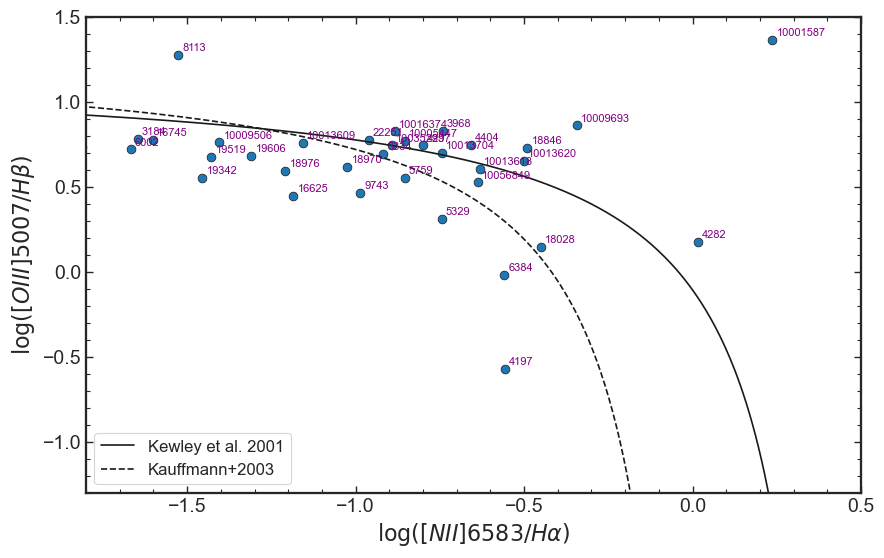

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#================= Plot Settings =================#
# Latex rendering
#plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
#plt.rc('text', usetex=True)
#plt.rc('font', weight='bold')


sns.set_theme(
    style="ticks",
    context='paper',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": False,
    })


#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def compute_axes(source='MAST', filter='G235M'):
    #================= File Reading =================#
    # Read the TSV file
    df_g235m = pd.read_csv('./Output_data/Line_fluxes_g235m.tsv', sep='\t')
    df_g395m = pd.read_csv('./Output_data/Line_fluxes_g395m.tsv', sep='\t')
    df_g395h = pd.read_csv('./Output_data/Line_fluxes_g395h.tsv', sep='\t')
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')

    if source == 'MAST':
        suffix = f'MAST {filter}'
        label_prefix = 'MAST'
        save_name = './Output_data/BPT_diagram_mast.pdf'
    elif source == 'JADES':
        suffix = f'JADES {filter}'
        label_prefix = 'JADES'
        save_name = './Output_data/BPT_diagram_jades.pdf'
    

    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    lines_for_plot = [
        f'Flux ([OIII]5007) {suffix}',
        f'Flux (Hb 4861) {suffix}',
        f'Flux ([NII]6583) {suffix}',
        f'Flux (Ha 6563) {suffix}',
        f'F_err([NII]6583) {suffix}',
    ]


    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])

    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
    }

    return pd.DataFrame(result)
#====================================================================#
#====================================================================#

def plt_bpt(source='JADES', arrows=True, labels=False, save=False, show=True):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    x = []
    y = []

    for i in range(len(df_235)):
        if np.isfinite(df_235['blue_axis'].iat[i]):
            x.append(df_235['red_axis'].iat[i])
            y.append(df_235['blue_axis'].iat[i])
        elif np.isfinite(df_395['blue_axis'].iat[i]):
            x.append(df_395['red_axis'].iat[i])
            y.append(df_395['blue_axis'].iat[i])
        elif np.isfinite(df_395H['blue_axis'].iat[i]):
            x.append(df_395H['red_axis'].iat[i])
            y.append(df_395H['blue_axis'].iat[i])
        else:
            x.append(np.nan)
            y.append(np.nan)

    

    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(10, 6.18))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-1.8, 0.5)
    plt.ylim(-1.3, 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()

    sns.scatterplot(x=x, y=y, s=40, color='tab:blue', edgecolor='k')

    if labels:
        for x, y, obj_id in zip(x, y, df_235['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='purple'
            )

    left_arrow = flux_n2_g235m < ferr_n2_g235m
    if arrows:
        for x, y in zip(x[g235m_left_arrow], y235[g235m_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='purple', alpha=0.6, lw=2.5, mutation_scale=10),
                va='center'
            )
    if save:
    plt.savefig('bpt_v2.pdf', bbox_inches='tight')

    if show:
        plt.show()


plt_bpt(labels=True)

In [ ]:

    # Extract the specific columns of interest
    flux_o3 = df_sub[f'Flux ([OIII]5007) {suffix}']
    flux_hb = df_sub[f'Flux (Hb 4861) {suffix}']
    flux_n2 = df_sub[f'Flux ([NII]6583) {suffix}']
    flux_ha = df_sub[f'Flux (Ha 6563) {suffix}']


    #print(flux_o3[1], '\t', flux_hb[1])

    for i in range(63):
        print(df_sub[f'Flux ([OIII]5007) {suffix}'][i], '\t', df_sub[f'Flux (Hb 4861) {suffix}'][i])
        print(blue_axis[i])



# Keep only rows with valid flux measurements in the G235M and G395M plots
    df_sub = df_sub.dropna(subset=lines_for_plot)
    


    

    # Only keep combined rows whose IDs are not already in the valid G235M or G395M samples
    existing_ids = pd.Index(df_g235m_sub['ID']).append(pd.Index(df_g395m_sub['ID'])).unique()
    df_combn_only = df_combn_sub[~df_combn_sub['ID'].isin(existing_ids)].copy()

    # Require all four line fluxes for the combined-only sample
    df_combn_only = df_combn_only.dropna(subset=plot_cols)
    #================= Calculations for the plot =================#
    # Calculate log ratios (x and y for scatter plot)
    y235 = np.log10(flux_o3_g235m / flux_hb_g235m)
    x235 = np.log10(flux_n2_g235m / flux_ha_g235m)

    y395 = np.log10(flux_o3_g395m / flux_hb_g395m)
    x395 = np.log10(flux_n2_g395m / flux_ha_g395m)

    ferr_n2_g235m = df_g235m_sub[f'F_err([NII]6583) {suffix}']
    

    ferr_n2_g395m = df_g395m_sub[f'F_err([NII]6583) {suffix}']
    g395_left_arrow = flux_n2_g395m < ferr_n2_g395m

    flux_o3_combn = df_combn_only[f'Flux ([OIII]5007) {suffix}']
    flux_hb_combn = df_combn_only[f'Flux (Hb 4861) {suffix}']
    flux_n2_combn = df_combn_only[f'Flux ([NII]6583) {suffix}']
    flux_ha_combn = df_combn_only[f'Flux (Ha 6563) {suffix}']
    ferr_n2_combn = df_combn_only[f'F_err([NII]6583) {suffix}']
    combn_left_arrow = flux_n2_combn < ferr_n2_combn

    ycombn = np.log10(flux_o3_combn / flux_hb_combn)
    xcombn = np.log10(flux_n2_combn / flux_ha_combn)

    
    plt.scatter(x235, y235, alpha=0.6, color='purple', label=f'{label_prefix} G235M')
    plt.scatter(x395, y395, alpha=0.6, color='grey', label=f'{label_prefix} G395M')
    plt.scatter(xcombn, ycombn, alpha=0.6, color='teal', label=f'{label_prefix} Combined only')


    #Add arrows of upper limits for [NII]6583 fluxes where the flux is less than the error
    

        for x, y in zip(x395[g395_left_arrow], y395[g395_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='grey', lw=2.5, mutation_scale=12),
                va='center'
            )

        for x, y in zip(xcombn[combn_left_arrow], ycombn[combn_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='teal', lw=2.5, mutation_scale=12),
                va='center'
            )

   

        for x, y, obj_id in zip(x395, y395, df_g395m_sub['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='grey'
            )

        for x, y, obj_id in zip(xcombn, ycombn, df_combn_only['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='teal'
            )

    plt.legend(loc='lower left')
    

"""